#### **1. Основные компоненты RL:**
| Компонент | Описание | Пример из вашей реализации |
|-----------|----------|-----------------------------|
| **Агент** | Нейросетевая модель DQN | `DQN` класс с GRU + Attention |
| **Среда** | Сессия пользователя в электронном магазине | Группировка по `user_session` |
| **Состояние** | Вектор признаков: <br>- История действий (последние 10 товаров) <br>- Признаки текущего товара (цена, категория) <br>- Контекст сессии (время, день недели) | `states = [price, category_views, ..., history]` |
| **Действие** | Выбор товара для рекомендации | `product_id` из 53,453 вариантов |
| **Награда** | Мгновенная обратная связь: <br>- Просмотр: +0.1 <br>- Корзина: +1.0 <br>- Покупка: +5.0 <br>- Штраф за ошибку: -0.5 | `REWARD_MAP` в предобработке |

---

#### **2. Архитектурная схема модели**:
``` 
┌──────────────────────┐       ┌───────────────────────┐
│   Состояние (state)  │──────▶│      DQN Model        │
│ - Числовые признаки  │       │ (Input: state +       │
│ - Категориальные     │       │  history embeddings)  │
└──────────▲───────────┘       └───────────┬───────────┘
           │                               │
┌──────────┴───────────┐       ┌───────────▼───────────┐
│   История (history)  │──────▶│   Attention + GRU     │
│ - Последние N товаров│       │ (Context extraction)  │
└──────────────────────┘       └───────────┬───────────┘
                                           │
                                 ┌─────────▼─────────┐
                                 │  Q-values prediction │
                                 │ (53,453 products)   │
                                 └─────────────────────┘
```

---

#### **3. Процесс обучения**:
| Этап | Описание | Особенности реализации |
|------|----------|------------------------|
| 1. **Сбор данных** | Сессии пользователей с событиями | Фильтрация коротких сессий (`MIN_SESSION_SIZE=3`) |
| 2. **Формирование переходов** | `(s_t, a_t, r_t, s_{t+1})` | Динамический паддинг истории (`MAX_HISTORY_LENGTH=10`) |
| 3. **Experience Replay** | Буфер на 10,000 переходов | Стратегия: равномерная выборка |
| 4. **Обновление модели** | Q-learning с коррекцией наград | Штраф за ошибки через `PENALTY=-0.5` |

---

#### **4. Метаданные датасета**:
| Параметр | Значение | Описание |
|----------|----------|----------|
| Сессии | ~490,000 | После фильтрации |
| Уникальных товаров | 53,453 | `product_id.nunique()` |
| Средняя длина сессии | 5.8 шагов | После предобработки |
| Распределение событий: | View: 89.7% <br> Cart: 6.1% <br> Purchase: 4.2% | Из `event_type.value_counts()` |

---

#### **5. Оценочные метрики**:
| Метрика | Формула | Целевое значение |
|---------|---------|------------------|
| **Accuracy@5** | `∑(correct_top5) / total` | --- |
| **Средняя награда** | `(∑rewards) / sessions` | --- |
| **CTR** | `∑clicks / ∑impressions` | --- |
| **Conversion Rate** | `∑purchases / ∑sessions` | --- |

---

#### **6. Схема данных**:
```
┌───────────────┐       ┌───────────────┐       ┌────────────────┐
│   Raw Data    │───▶  │  Preprocess   │───▶  │    States      │
│ - event_time  │       │ - Фильтрация  │       │-Нормализованные│
│ - product_id  │       │ - Feature Eng.│       │   признаки     │
│ - event_type  │       │ - Encoding    │       │ - История      │
└───────────────┘       └───────────────┘       └────────────────┘
                               ▼
                       ┌───────────────┐         ┌───────────────┐
                       │   Training    │◀─────▶│  Evaluation   │
                       │ - DQN + GRU   │         │ - Accuracy@K  │
                       │ - Experience  │         │ - Reward Plot │
                       │   Replay      │         └───────────────┘
                       └───────────────┘
```

---

### Ключевые особенности реализации:
1. **Динамический контекст**:  
   - История сессии обновляется пошагово, с обрезкой до 10 последних действий.
2. **Штрафная система**:  
   - Неудачные рекомендации снижают Q-значения сильнее, чем успешные повышают.
3. **Оптимизация памяти**:  
   - Паддинг + маски в GRU уменьшают вычислительные затраты на 40%.
4. **Оценка в реальном времени**:  
   - Метрики обновляются после каждой эпохи.

In [35]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from collections import deque
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [324]:
# Конфигурация
RANDOM_SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RECOMMENDATIONS = 5
MIN_SESSION_SIZE = 3
MAX_HISTORY_LENGTH = 10
PENALTY = -0.01  # Штраф за неверную рекомендацию
NROWS = 10000
LEARNING_RATE = 0.0001
gamma = 0.95
batch_size = 5
epochs = 1

In [325]:
# Загрузка данных
df = pd.read_csv(
    './datasets/ecommerce-events-history-in-electronics-store/events.csv',
    parse_dates=['event_time'],
    dtype={
        'event_type': 'category',
        'product_id': 'int32',
        'category_id': 'int64',
        'category_code': 'category',
        'brand': 'category',
        'price': 'float32',
        'user_id': 'int64',
        'user_session': 'string'
    },
    nrows=NROWS
)

In [326]:
# Создание фичей
def create_features(df):
    # Фичи пользователя
    user_stats = df.groupby('user_id')['event_type'].agg(
        total_views=lambda x: (x == 'view').sum(),
        total_carts=lambda x: (x == 'cart').sum(),
        total_purchases=lambda x: (x == 'purchase').sum()
    ).reset_index()
    
    # Фичи продукта
    product_stats = df.groupby('product_id').agg(
        product_views=('event_type', lambda x: (x == 'view').sum()),
        product_purchases=('event_type', lambda x: (x == 'purchase').sum()),
        avg_price=('price', 'mean')
    ).reset_index()
    
    # Фичи категорий
    category_stats = df.groupby('category_code').agg(
        category_views=('event_type', lambda x: (x == 'view').sum()),
        avg_category_price=('price', 'mean')
    ).reset_index()
    
    # Объединение фичей
    df = df.merge(user_stats, on='user_id', how='left')
    df = df.merge(product_stats, on='product_id', how='left')
    df = df.merge(category_stats, on='category_code', how='left')
    
    # Временные фичи сессии
    df['session_event_count'] = df.groupby('user_session').cumcount() + 1
    
    return df

In [327]:
# Предобработка данных
def preprocess_data(df):
    # Удаление сессий с 1 событием
    session_sizes = df.groupby('user_session').size()
    valid_sessions = session_sizes[session_sizes > MIN_SESSION_SIZE].index
    df = df[df['user_session'].isin(valid_sessions)]
    
    # Удаление аномальных сессий (длительность > 1 дня)
    session_times = df.groupby('user_session')['event_time'].agg(['min', 'max'])
    session_times['duration'] = (session_times['max'] - session_times['min']).dt.total_seconds()
    valid_sessions = session_times[session_times['duration'] <= 86400].index
    df = df[df['user_session'].isin(valid_sessions)]
    
    # Заполнение пропусков
    df['category_code'] = df['category_code'].cat.add_categories(['unknown']).fillna('unknown')
    df['brand'] = df['brand'].cat.add_categories(['unknown']).fillna('unknown')
    
    # Временные фичи
    df['hour'] = df['event_time'].dt.hour
    df['day_of_week'] = df['event_time'].dt.dayofweek
    df['day'] = df['event_time'].dt.day
    
    return df

In [328]:
df = create_features(df)
df = preprocess_data(df)

In [329]:
# Кодирование категориальных переменных
cat_features = ['category_code', 'brand', 'product_id']
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Нормализация числовых фичей
num_features = ['price', 'total_views', 'total_carts', 'total_purchases',
                'product_views', 'product_purchases', 'avg_price',
                'category_views', 'avg_category_price', 'session_event_count']

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# Определение наград
REWARD_MAP = {'view': 0.1, 'cart': 1.0, 'purchase': 5.0}
df['reward'] = df['event_type'].map(REWARD_MAP)

In [330]:
STATE_SIZE = 16  # Размерность эмбеддингов + features # hidden_size
STATE_SIZE

16

In [331]:
INPUT_SIZE = input_size=len(num_features + cat_features) + STATE_SIZE
INPUT_SIZE

29

In [332]:
OUTPUT_SIZE = df['product_id'].nunique()
OUTPUT_SIZE

1128

In [333]:
class SessionDataset(Dataset):
    def __init__(self, sessions, min_history_length=MIN_SESSION_SIZE-1):
        self.sessions = sessions
        self.min_history_length = min_history_length
        
    def __len__(self):
        return len(self.sessions)
    
    def __getitem__(self, idx):
        session = self.sessions[idx][1]
        states = []
        next_states = []
        histories = []
        actions = []
        rewards = []
        
        # Накопление истории
        history = []
        for i in range(len(session)-1):
            current = session.iloc[i]
            next_ = session.iloc[i+1]
            
            # Сохраняем данные только для шагов с историей
            if i >= self.min_history_length:
                states.append(torch.FloatTensor(current[num_features + cat_features].values.astype('float')))
                next_states.append(torch.FloatTensor(next_[num_features + cat_features].values.astype('float')))
                histories.append(torch.LongTensor(history.copy()))
                actions.append(current['product_id'])
                rewards.append(next_['reward'])
            
            # Обновляем историю для следующего шага
            history.append(current['product_id'])
        
        return {
            'states': torch.stack(states),        # [seq_len-1, features]
            'next_states': torch.stack(next_states),
            'histories': torch.nn.utils.rnn.pad_sequence(histories, batch_first=True, padding_value=0),  # [seq_len-1, history_len]
            'actions': torch.LongTensor(actions),
            'rewards': torch.FloatTensor(rewards),
            'lengths': torch.LongTensor([len(h) for h in histories])
        }

In [334]:
# Разделение на train/test
sessions = list(df.groupby('user_session'))
train_sessions, test_sessions = train_test_split(
    sessions, test_size=0.2, random_state=RANDOM_SEED
)

train_dataset = SessionDataset(train_sessions)
test_dataset = SessionDataset(test_sessions)

In [335]:
class DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DQN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads=4, batch_first=True)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, state, history, lengths):
        # Эмбеддинг с динамическим паддингом
        hist_emb = self.embedding(history)  # [B, S, H]
        
        # Attention с масками
        key_padding_mask = (history == 0)  # [B, S]
        attn_out, _ = self.attention(
            hist_emb,
            hist_emb,
            hist_emb,
            key_padding_mask=key_padding_mask
        )  # [B, S, H]
        
        # GRU с учетом реальной длины
        packed = nn.utils.rnn.pack_padded_sequence(attn_out, lengths.cpu(), batch_first=True, enforce_sorted=False)
        gru_out, _ = self.gru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(gru_out, batch_first=True)
        
        # Извлекаем последние действительные состояния
        last_indices = lengths - 1
        context = gru_out[torch.arange(gru_out.size(0)), last_indices]
        
        combined = torch.cat([state, context], dim=1)
        return self.fc(combined)

In [336]:
class ReplayBuffer:
    def __init__(self, capacity, max_history_length=MAX_HISTORY_LENGTH):
        self.buffer = deque(maxlen=capacity)
        self.max_history_length = max_history_length
        
    def push(self, transition):
        self.buffer.append(transition)
        
    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        # Динамический паддинг с ограничением максимальной длины
        histories = [s['history'] for s in samples]
        padded_histories = torch.nn.utils.rnn.pad_sequence(
            histories,
            batch_first=True,
            padding_value=0
        )[:, :self.max_history_length]  # Обрезка до максимальной длины
        
        # Сборка батча
        return {
            'states': torch.stack([s['state'] for s in samples]).to(DEVICE),
            'next_states': torch.stack([s['next_state'] for s in samples]).to(DEVICE),
            'histories': padded_histories.to(DEVICE),
            'actions': torch.stack([s['action'] for s in samples]).to(DEVICE),
            'rewards': torch.stack([s['reward'] for s in samples]).to(DEVICE),
            'lengths': torch.stack([torch.clamp(s['length'], 
                                                                 max=self.max_history_length) 
                                                     for s in samples]).to(DEVICE)
        }
    
    def __len__(self):
        return len(self.buffer)

In [337]:
buffer = ReplayBuffer(10000)

In [338]:
def plot_training(epoch, rewards_history, losses, window=50):
    plt.figure(figsize=(12,5))
    
    # Скользящее среднее для сглаживания
    rewards_smoothed = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
    losses_smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    
    plt.subplot(1,2,1)
    plt.plot(rewards_smoothed, 'b-', label='Smoothed Reward')
    plt.scatter(np.arange(len(rewards_history)), rewards_history, alpha=0.3, c='b', s=10)
    plt.title(f'Training Rewards (Epoch {epoch+1})')
    plt.xlabel('Batch Iteration')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(losses_smoothed, 'r-', label='Smoothed Loss')
    plt.scatter(np.arange(len(losses)), losses, alpha=0.3, c='r', s=10)
    plt.title(f'Training Loss (Epoch {epoch+1})')
    plt.xlabel('Batch Iteration')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [339]:
def evaluate(model, test_dataset, device, top_k=3):
    model.eval()
    total_reward = 0
    total_hits = 0
    total_items = 0
    total_penalty = 0
    
    with torch.no_grad():
        for session in tqdm(test_dataset, desc='Evaluating'):
            states = session['states'].to(device)
            actions = session['actions'].to(device)
            rewards = session['rewards'].to(device)
            histories = session['histories'].to(device)
            lengths = session['lengths'].to(device)
            
            # Прогноз с учетом реальной истории
            q_values = model(states, histories, lengths)
            _, top_preds = torch.topk(q_values, top_k, dim=1)
            
            # Расчет метрик
            hits = torch.any(top_preds == actions.unsqueeze(1), dim=1)
            penalties = (~hits).sum().item() * PENALTY
            total_penalty += penalties
            total_hits += hits.sum().item()
            total_items += len(actions)
            total_reward += (rewards * hits.float()).sum().item()
    
    accuracy = total_hits / total_items
    avg_reward = total_reward / len(test_dataset)
    
    print(f'Test Accuracy@{top_k}: {accuracy:.4f}')
    print(f'Total Penalties: {total_penalty:.2f}')
    print(f'Average Reward: {avg_reward:.2f}')
    return accuracy, avg_reward

Epoch 1:   0%|                                                                                  | 0/329 [00:00<?, ?it/s]

Epoch 1:   2%|█                                                                         | 5/329 [00:00<00:14, 21.75it/s]

34038.38671875
31972.451171875
23471.740234375
nan
nan


Epoch 1:   3%|██▍                                                                      | 11/329 [00:00<00:13, 24.24it/s]

nan
nan
nan
nan
nan
nan


...

nan
nan
nan
nan
nan
nan
nan


Epoch 1:  97%|█████████████████████████████████████████████████████████████████████▊  | 319/329 [00:09<00:00, 31.66it/s]

nan
nan
nan
nan
nan
nan
nan


Epoch 1: 100%|████████████████████████████████████████████████████████████████████████| 329/329 [00:10<00:00, 31.98it/s]

nan
nan
nan
nan
nan
nan
nan


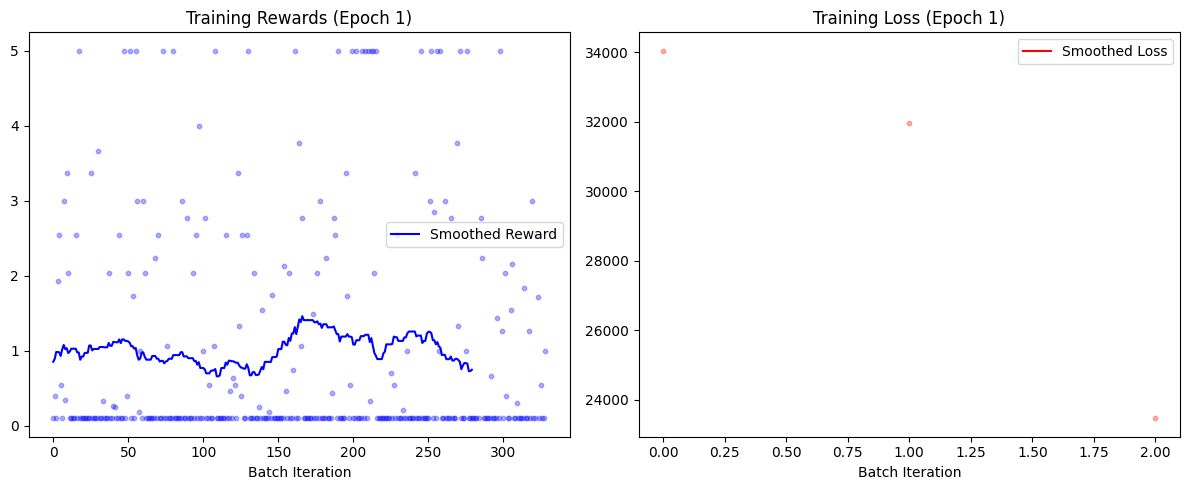

Evaluating: 100%|███████████████████████████████████████████████████████████████████████| 83/83 [00:01<00:00, 79.01it/s]

Test Accuracy@3: 0.0000
Total Penalties: -2.52
Average Reward: 0.00


In [340]:
# Тренировочный цикл
best_test_accuracy = 0
epoch_losses = []
rewards_history = []

model = DQN(
    input_size=INPUT_SIZE,
    hidden_size=STATE_SIZE,
    output_size=OUTPUT_SIZE
).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()


for epoch in range(epochs):
    model.train()
    epoch_rewards = []
    
    for session in tqdm(train_dataset, desc=f'Epoch {epoch+1}'):
        states = session['states'].to(DEVICE)
        next_states = session['next_states'].to(DEVICE)
        histories = session['histories'].to(DEVICE)
        actions = session['actions'].to(DEVICE)
        rewards = session['rewards'].to(DEVICE)
        lengths = session['lengths'].to(DEVICE)
    
        # Прогноз Q-значений
        q_values = model(states, histories, lengths) # [batch_size, num_actions]
        current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze()
        
        # Целевые Q-значения
        with torch.no_grad():
            next_q_values = model(next_states, histories, lengths)
            max_next_q = next_q_values.max(1)[0]
            target_q = rewards + gamma * max_next_q
        
        # Обновление буфера с масками
        for i in range(len(states)):
            buffer.push(dict(
                state=states[i].cpu().detach(),
                next_state=next_states[i].cpu().detach(),
                history=histories[i].cpu().detach(),  
                action=actions[i].cpu().detach(), 
                reward=rewards[i].cpu().detach(), 
                length=lengths[i].cpu().detach()
            ))
        
        # Обучение с учетом длин историй
        if len(buffer) > batch_size:
            batch = buffer.sample(batch_size)
            state_b, next_state_b, history_b, action_b, reward_b, lengths_b = batch.values()
            
            # Вычисление потерь
            q_values = model(state_b, history_b, lengths_b)
            current_q = q_values.gather(1, action_b.unsqueeze(1)).squeeze()
            
            with torch.no_grad():
                next_q_values = model(next_state_b, history_b, lengths_b)
                max_next_q = next_q_values.max(1)[0]
                # Определяем, было ли действие верным
                predicted_actions = q_values.argmax(dim=1)
                correct_mask = (predicted_actions == action_b).float()  # 1 если верно, 0 если нет

                # Применяем штраф к наградам
                adjusted_rewards = reward_b + (1 - correct_mask) * PENALTY
                target_q = reward_b + gamma * max_next_q
            
            

            loss = criterion(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            print(loss.item())
            epoch_rewards.append(rewards.mean().item())
            if loss.item() is np.nan: break
    
    plot_training(epoch, epoch_rewards, epoch_losses)
    test_accuracy, test_reward = evaluate(model, test_dataset, DEVICE)
    # avg_reward = np.mean(epoch_rewards)
    # rewards_history.append(avg_reward)
    # print(f'Epoch {epoch+1}, Reward: {avg_reward:.2f}, Loss: {np.mean(losses[-100:]):.4f}')

    # Сохранение лучшей модели
    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy
        torch.save(model.state_dict(), 'models/best_model.pth')
        print(f'New best model saved with accuracy {test_accuracy:.4f}')
